In [1]:
from pathlib import Path
import json
import sys
from typing import Any, Mapping, Sequence

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

# ---------------------------------------------------------------------------
# Task-specific paths
# ---------------------------------------------------------------------------
PROJECT_ROOT = Path("/home/hieule/research/reflector-position")
ARTIFACTS_DIR = Path(
    "/home/hieule/research/reflector-position/tmp_comparison_results1/office/per_trial_runs/aps_03_seed_0043/artifacts"
)
PER_TRIAL_RUNS_DIR = Path(
    "/home/hieule/research/reflector-position/tmp_comparison_results1/office/per_trial_runs"
)
RUN_TAG = ARTIFACTS_DIR.parent.name
OUTPUT_DIR = PER_TRIAL_RUNS_DIR / "recreated_static_plots" / RUN_TAG

# Keep legend order aligned with attached static plots.
# METHOD_ORDER = ["memetic", "random", "kmeans", "weighted_kmeans", "random_gd", "pso_gd"]
METHOD_ORDER = ["memetic", "random", "weighted_kmeans", "random_gd", "pso_gd"]

# RSSI range used by static_comparison_plotting.py
RSSI_Y_LIMITS = (-100.0, -40.0)

# Make src-layout package importable from notebook.
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from reflector_position.optimizers.baselines.static_comparison_plotting import save_static_comparison_plots

In [2]:
def _load_json(path: Path) -> Any:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def discover_methods(
    artifacts_dir: Path,
    preferred_order: Sequence[str] | None = None,
) -> list[str]:
    available_methods = sorted(
        p.name[: -len("_results.json")]
        for p in artifacts_dir.glob("*_results.json")
        if p.name.endswith("_results.json")
    )
    if preferred_order is None:
        return available_methods

    ordered = [method for method in preferred_order if method in available_methods]
    remaining = [method for method in available_methods if method not in ordered]
    return ordered + remaining


def load_method_artifacts(
    artifacts_dir: Path,
    methods: Sequence[str],
) -> tuple[dict[str, Mapping[str, Any]], dict[str, list[Mapping[str, Any]]]]:
    method_results: dict[str, Mapping[str, Any]] = {}
    method_trace_rows: dict[str, list[Mapping[str, Any]]] = {}

    for method in methods:
        result_path = artifacts_dir / f"{method}_results.json"
        trace_path = artifacts_dir / f"{method}_iteration_trace.json"

        if not result_path.exists():
            raise FileNotFoundError(f"Missing result file for method '{method}': {result_path}")

        result_payload = _load_json(result_path)
        if not isinstance(result_payload, Mapping):
            raise ValueError(f"Result file must contain a JSON object: {result_path}")

        if trace_path.exists():
            trace_payload = _load_json(trace_path)
        else:
            trace_payload = result_payload.get("iteration_trace", [])

        if not isinstance(trace_payload, list):
            trace_payload = []

        trace_rows = [row for row in trace_payload if isinstance(row, Mapping)]
        method_results[method] = dict(result_payload)
        method_trace_rows[method] = trace_rows

    return method_results, method_trace_rows


def recreate_static_plots_from_trial_artifacts(
    artifacts_dir: Path,
    output_dir: Path,
    method_order: Sequence[str] | None = None,
    rssi_y_limits: tuple[float, float] = (-100.0, -40.0),
) -> dict[str, Any]:
    methods = discover_methods(artifacts_dir=artifacts_dir, preferred_order=method_order)
    method_results, method_trace_rows = load_method_artifacts(
        artifacts_dir=artifacts_dir,
        methods=methods,
    )

    output_dir.mkdir(parents=True, exist_ok=True)
    plot_artifacts = save_static_comparison_plots(
        methods=methods,
        method_results=method_results,
        method_trace_rows=method_trace_rows,
        plots_dir=output_dir,
        rssi_y_limits=rssi_y_limits,
    )

    manifest = {
        "artifacts_dir": str(artifacts_dir),
        "output_dir": str(output_dir),
        "methods": methods,
        "rssi_y_limits": [float(rssi_y_limits[0]), float(rssi_y_limits[1])],
        "plot_artifacts": plot_artifacts,
    }
    manifest_path = output_dir / "recreated_plot_manifest.json"
    manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

    return {
        "methods": methods,
        "output_dir": output_dir,
        "manifest_path": manifest_path,
        "plot_artifacts": plot_artifacts,
    }


def _collect_png_paths(value: Any) -> list[Path]:
    if isinstance(value, str) and value.endswith(".png"):
        path = Path(value)
        return [path] if path.exists() else []
    if isinstance(value, Mapping):
        paths: list[Path] = []
        for nested in value.values():
            paths.extend(_collect_png_paths(nested))
        return paths
    if isinstance(value, list):
        paths = []
        for nested in value:
            paths.extend(_collect_png_paths(nested))
        return paths
    return []


def display_recreated_cross_method_plots(plot_artifacts: Mapping[str, Any]) -> None:
    all_png_paths = _collect_png_paths(plot_artifacts)

    cross_method_paths = [
        path for path in all_png_paths if path.name.startswith("all_methods_") and path.name.endswith("_static.png")
    ]

    order = [
        "all_methods_p5_rss_dbm_static.png",
        "all_methods_min_rss_dbm_static.png",
        "all_methods_mean_rss_dbm_static.png",
        "all_methods_priority_p5_rss_dbm_static.png",
        "all_methods_priority_min_rss_dbm_static.png",
        "all_methods_priority_mean_rss_dbm_static.png",
        "all_methods_primary_loss_static.png",
    ]
    order_index = {name: i for i, name in enumerate(order)}
    cross_method_paths = sorted(
        set(cross_method_paths),
        key=lambda path: (order_index.get(path.name, 999), path.name),
    )

    if not cross_method_paths:
        display(Markdown("No cross-method plots were generated."))
        return

    display(Markdown("## Recreated Cross-Method Static Plots"))
    for path in cross_method_paths:
        display(Markdown(f"### {path.name}"))
        display(Image(filename=str(path)))

Methods used: ['memetic', 'random', 'weighted_kmeans', 'random_gd', 'pso_gd', 'kmeans']
Output directory: /home/hieule/research/reflector-position/tmp_comparison_results1/office/per_trial_runs/recreated_static_plots/aps_03_seed_0043
Manifest: /home/hieule/research/reflector-position/tmp_comparison_results1/office/per_trial_runs/recreated_static_plots/aps_03_seed_0043/recreated_plot_manifest.json


## Recreated Cross-Method Static Plots

### all_methods_p5_rss_dbm_static.png

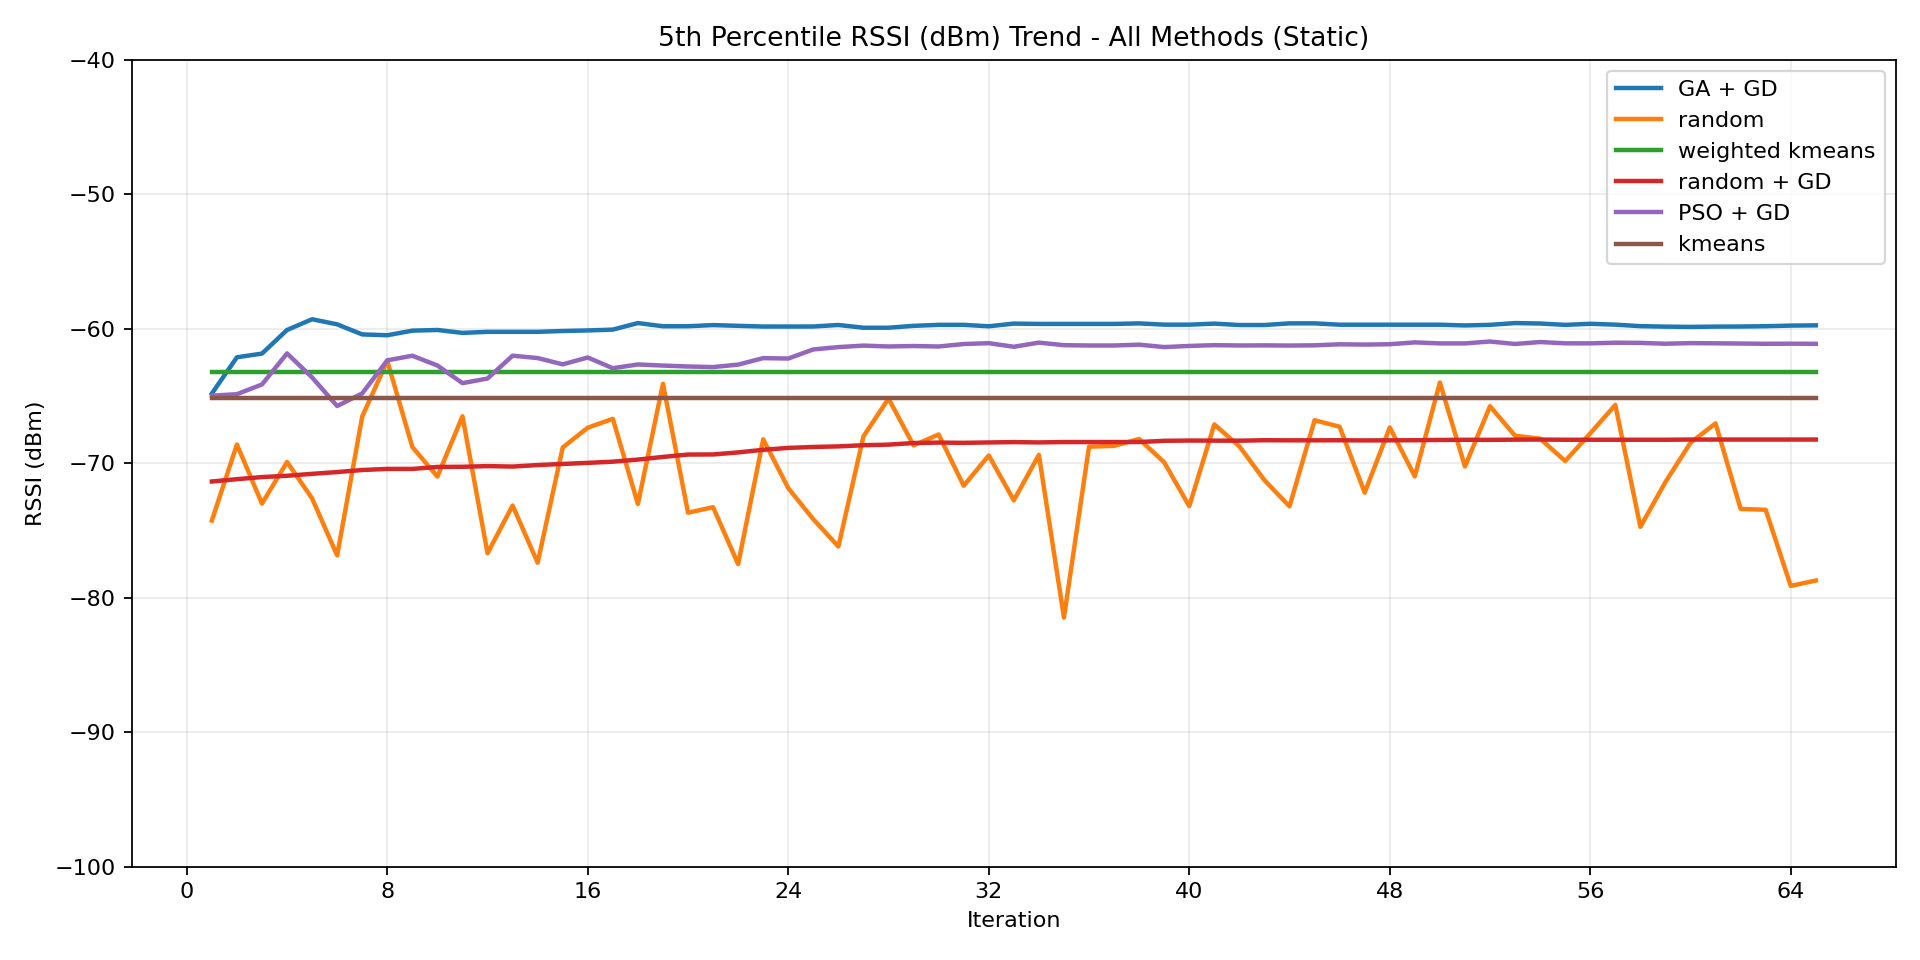

### all_methods_min_rss_dbm_static.png

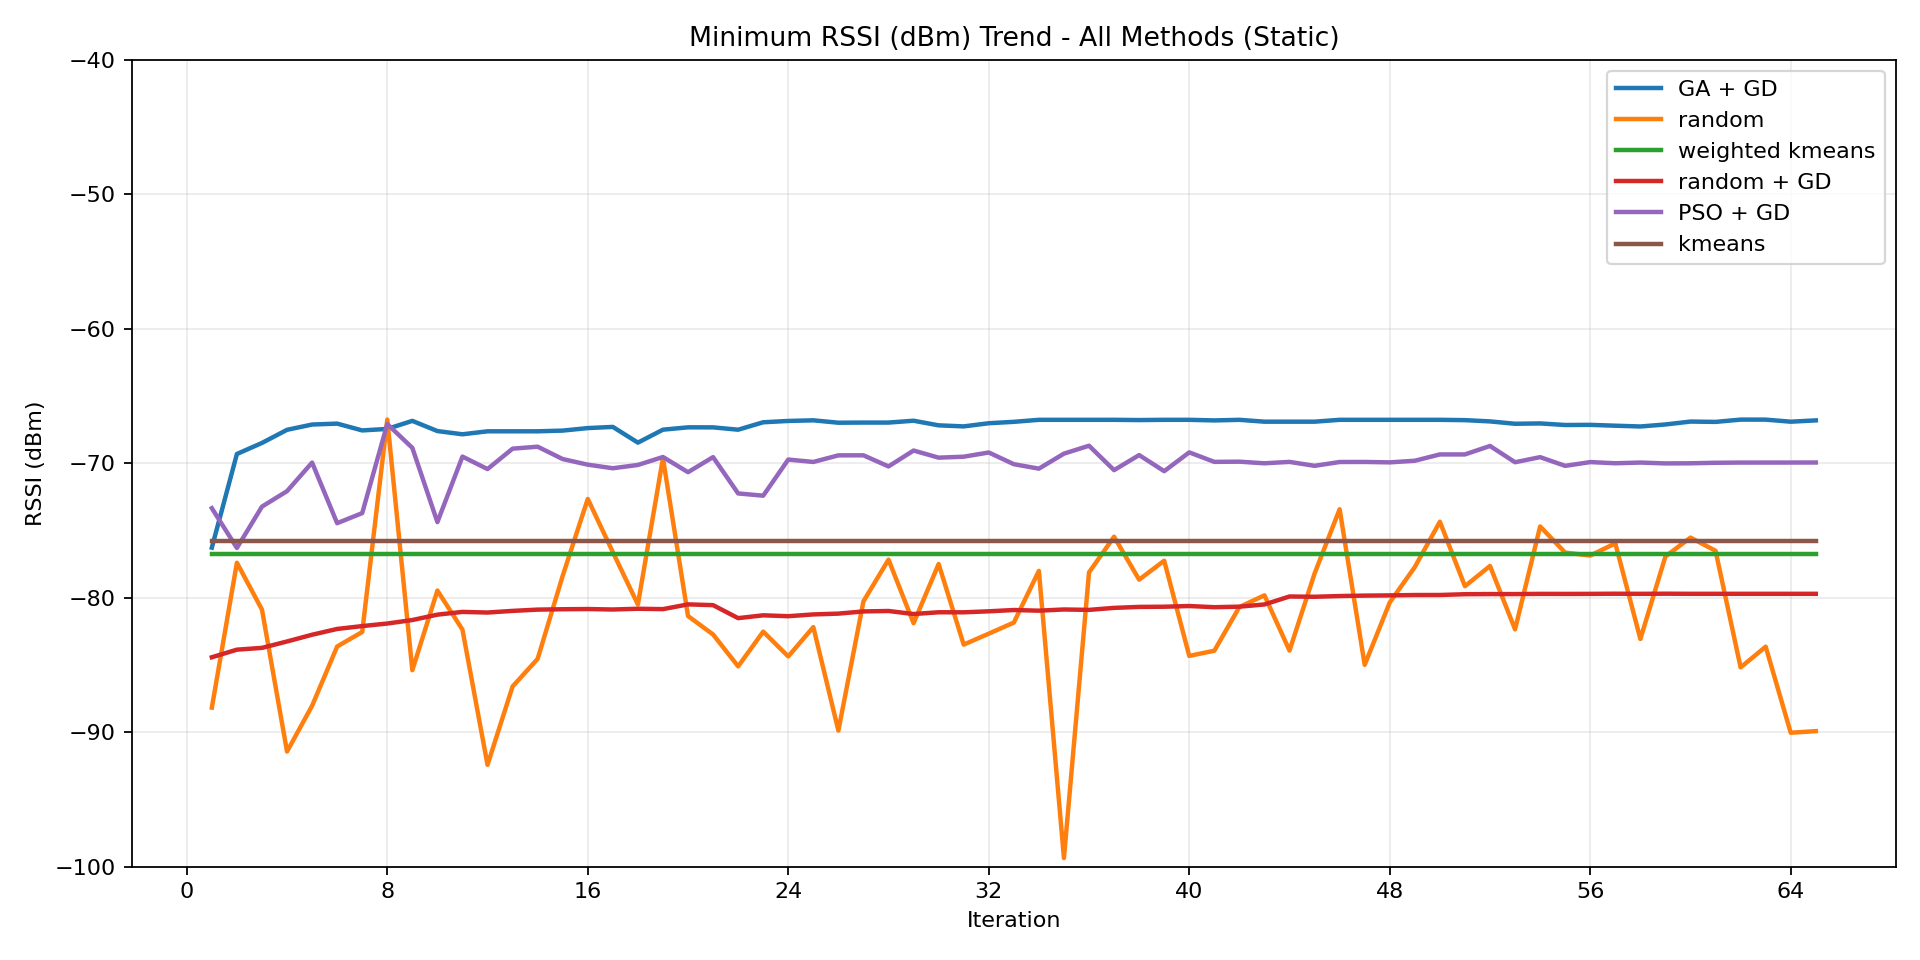

### all_methods_mean_rss_dbm_static.png

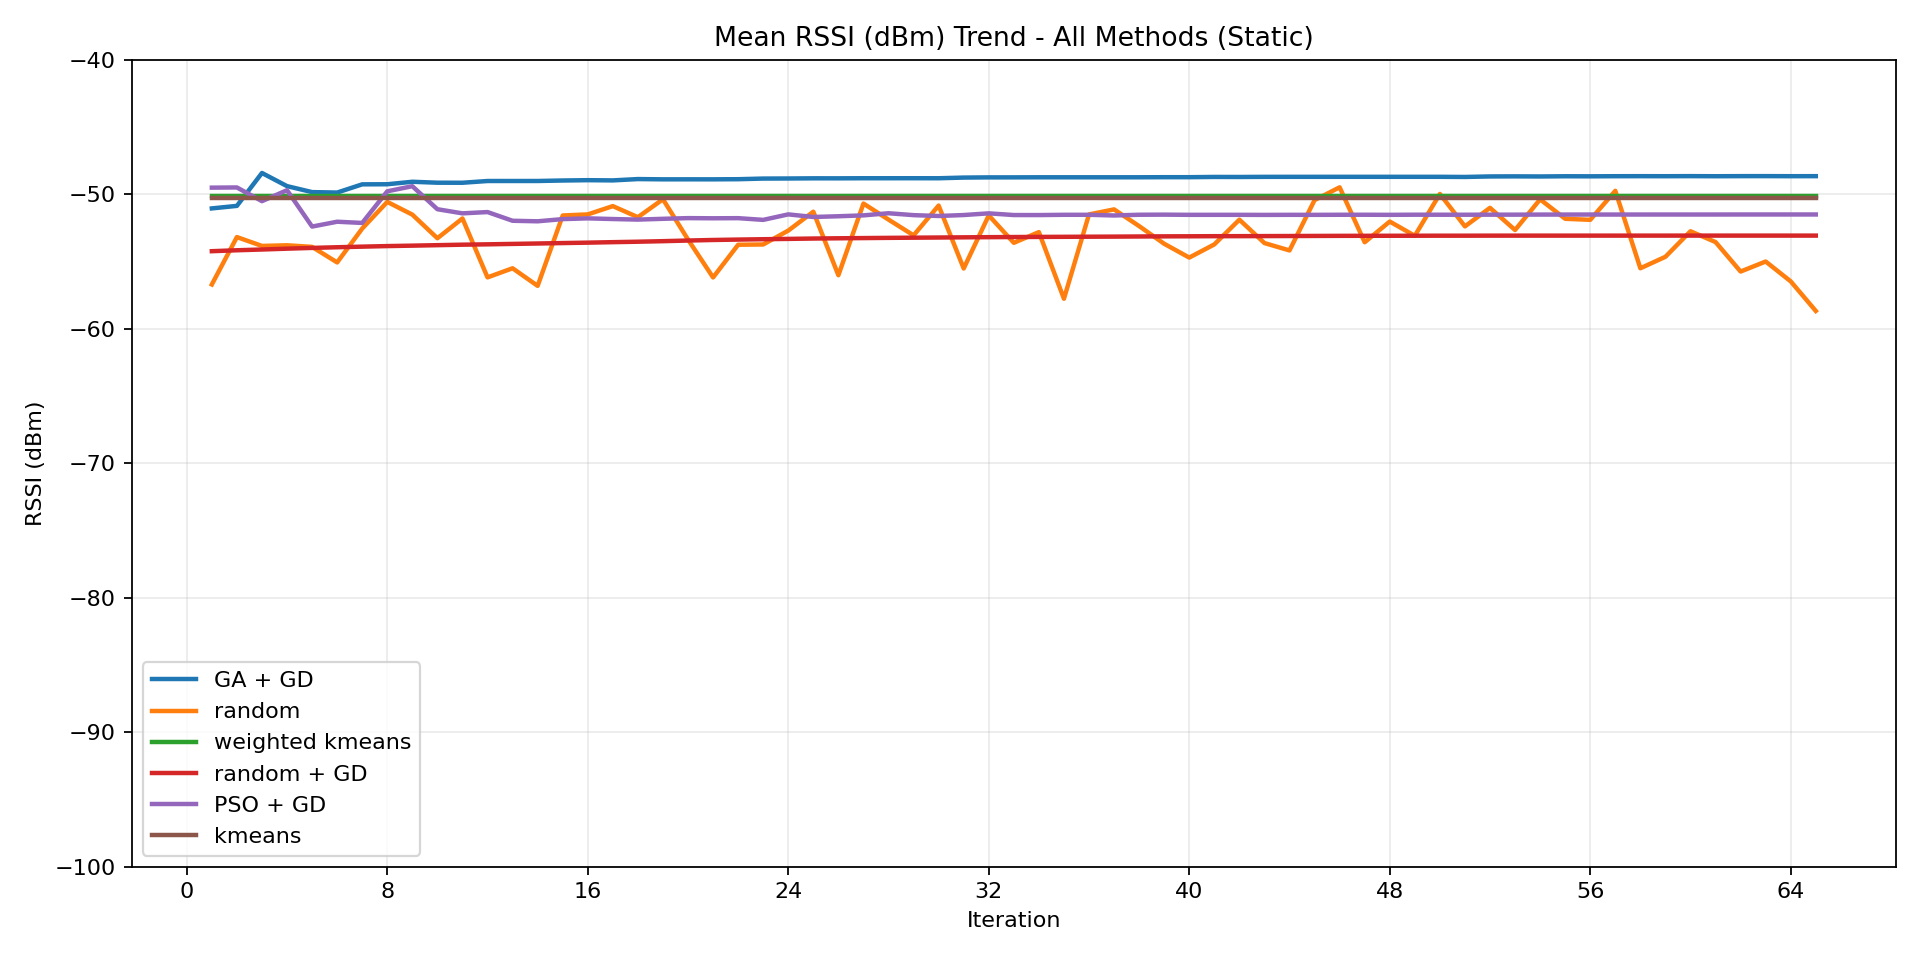

### all_methods_priority_p5_rss_dbm_static.png

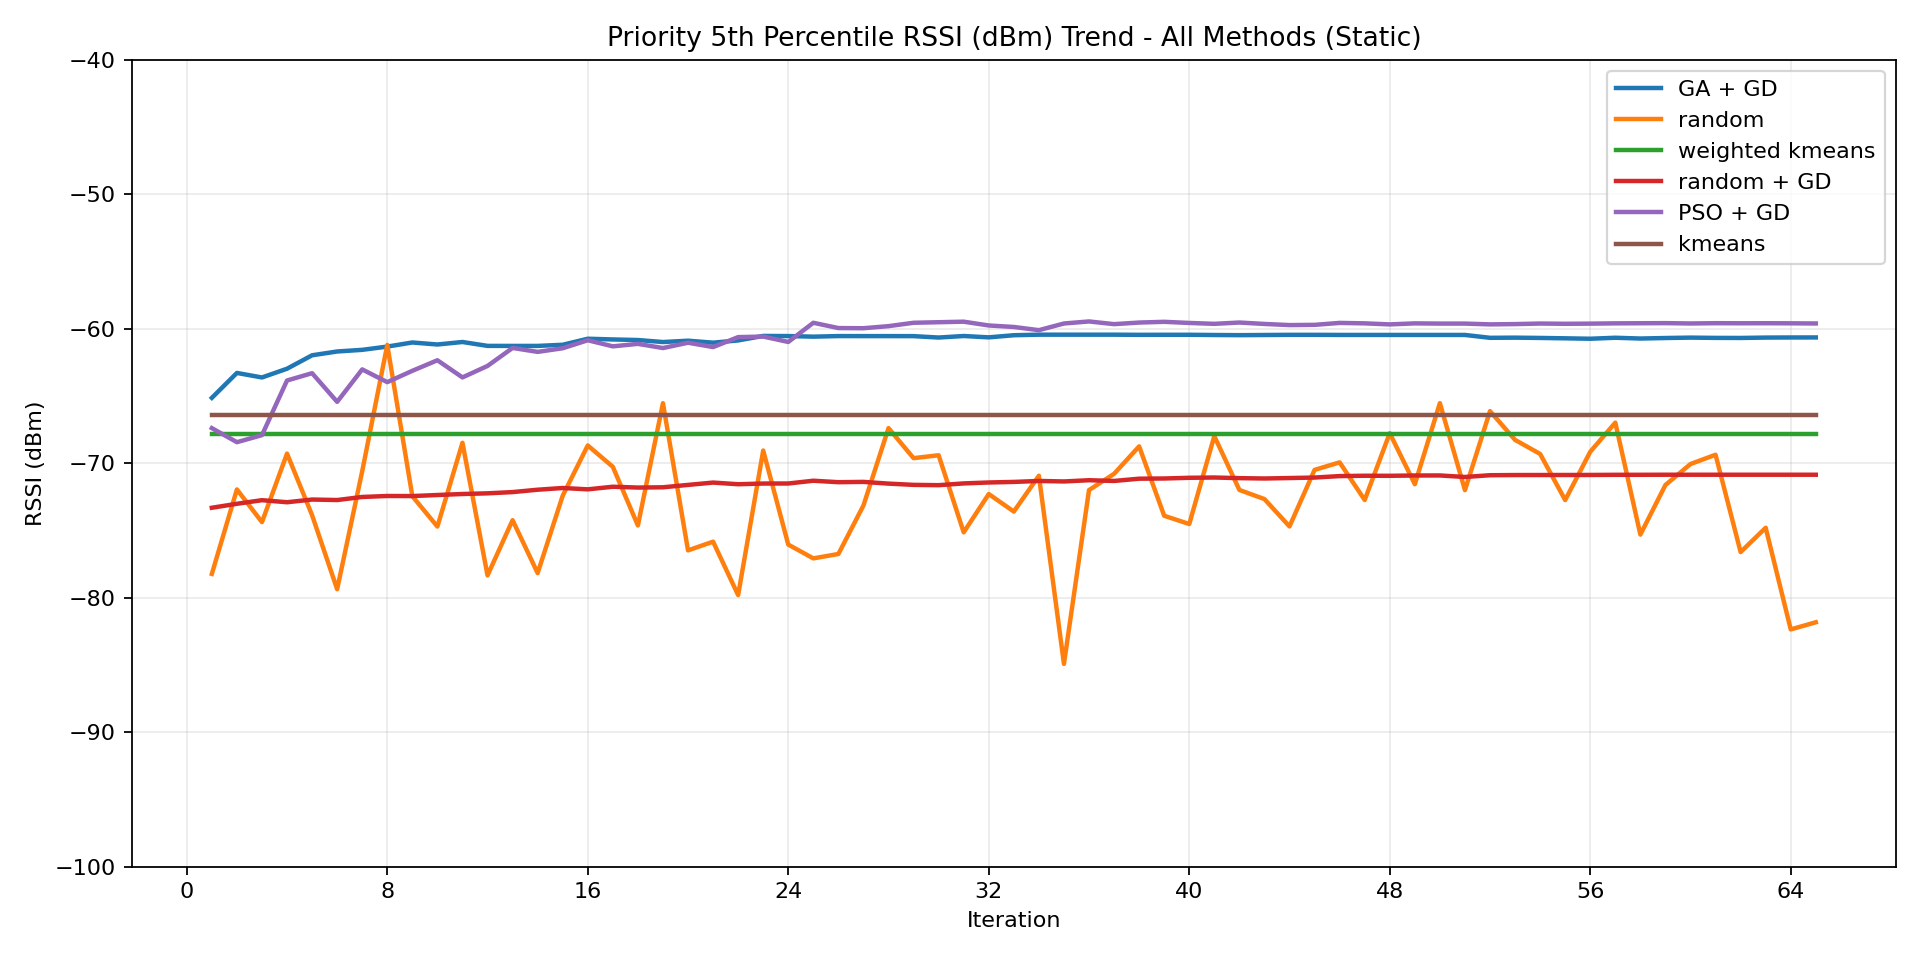

### all_methods_priority_min_rss_dbm_static.png

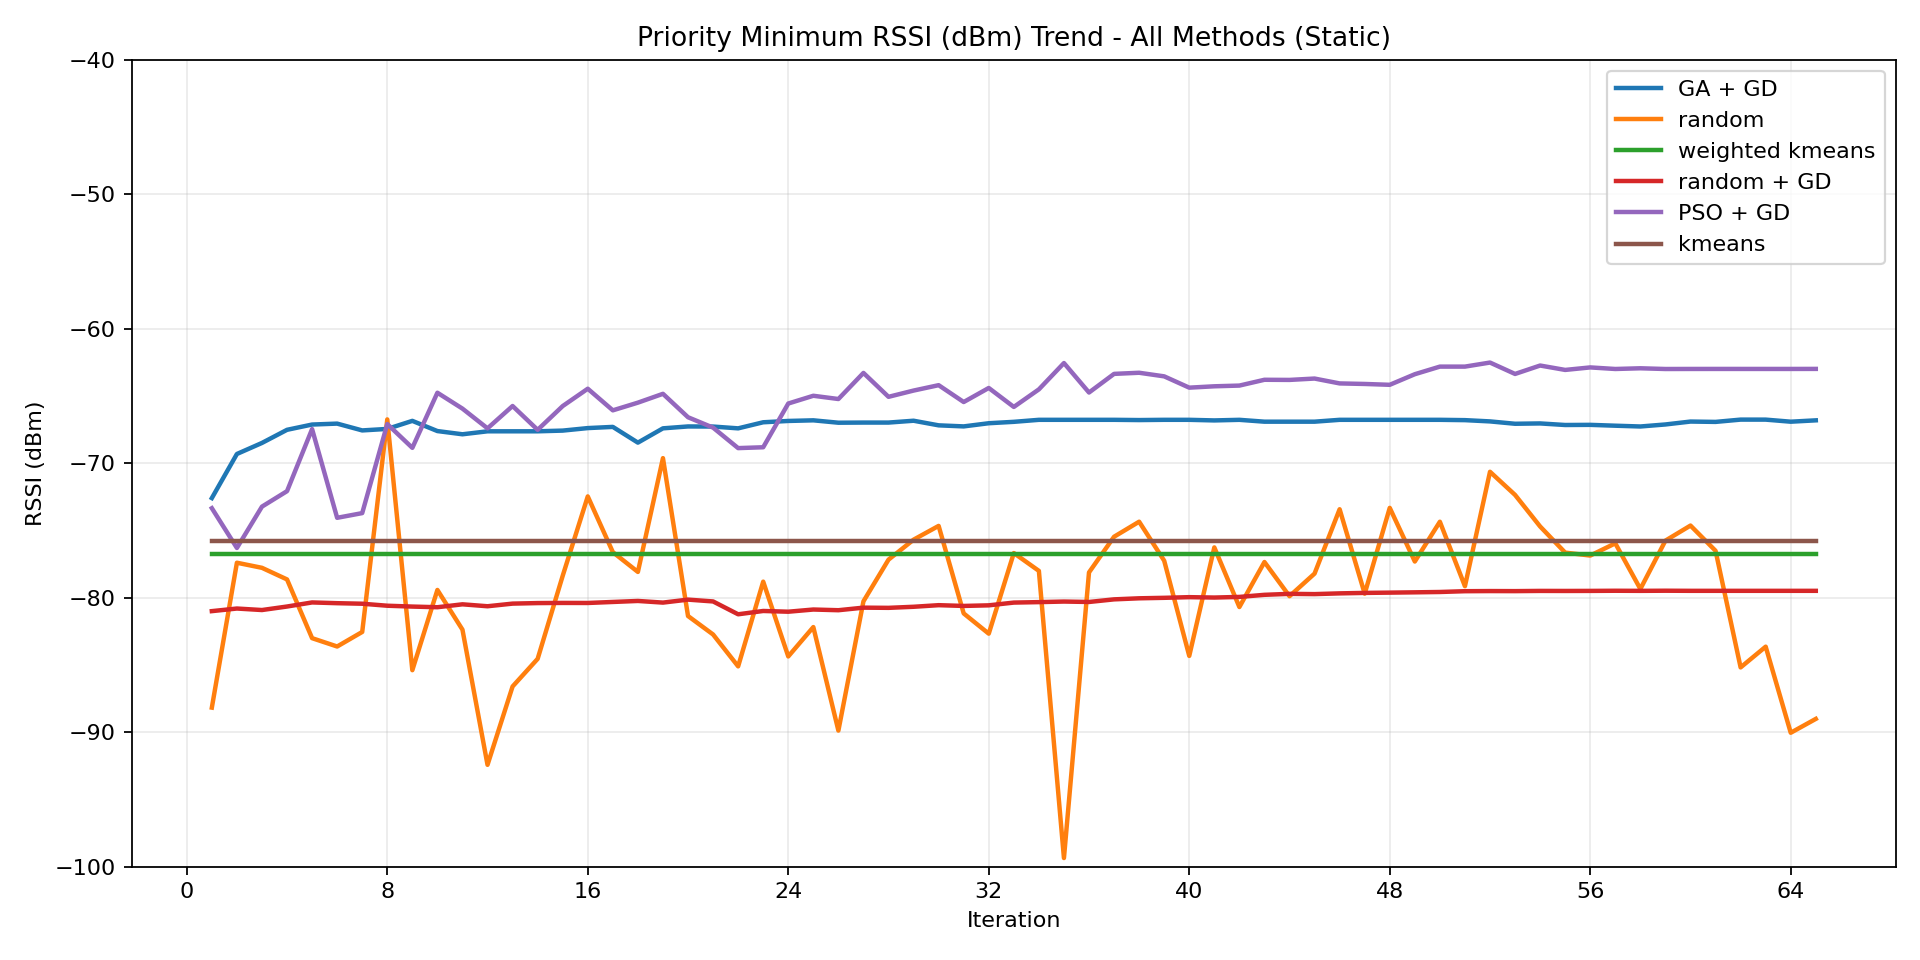

### all_methods_priority_mean_rss_dbm_static.png

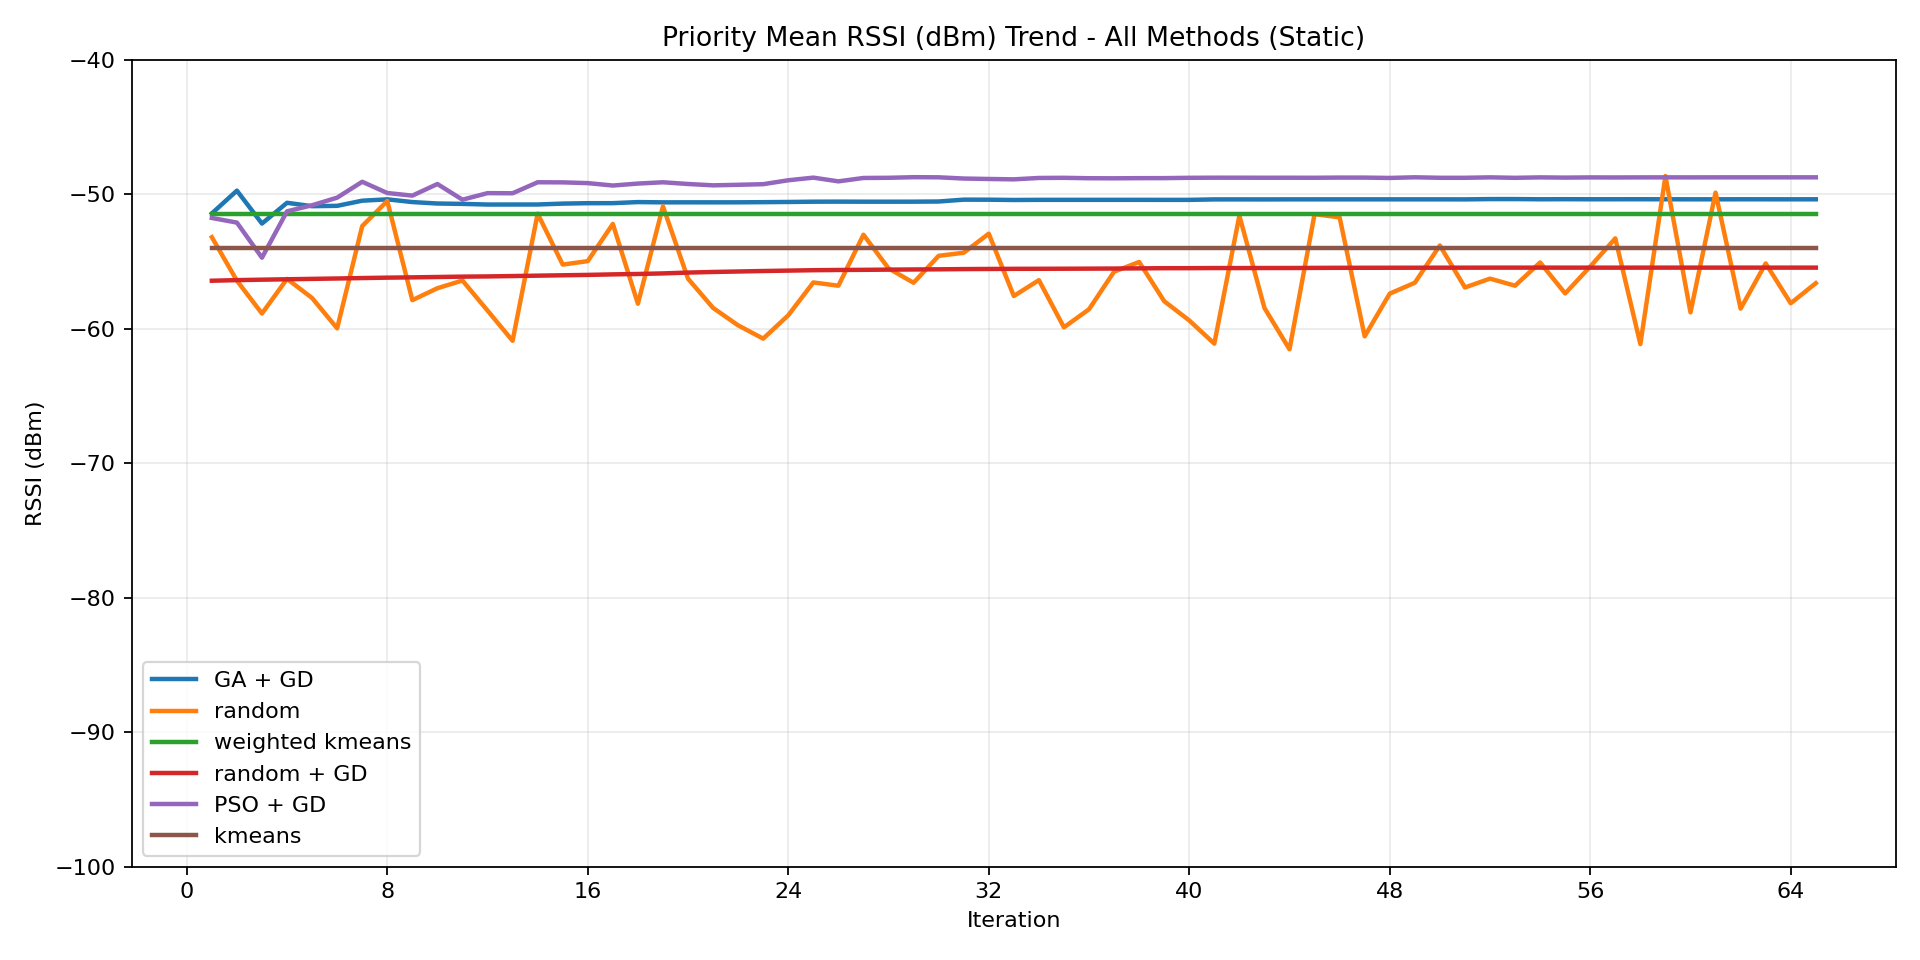

### all_methods_primary_loss_static.png

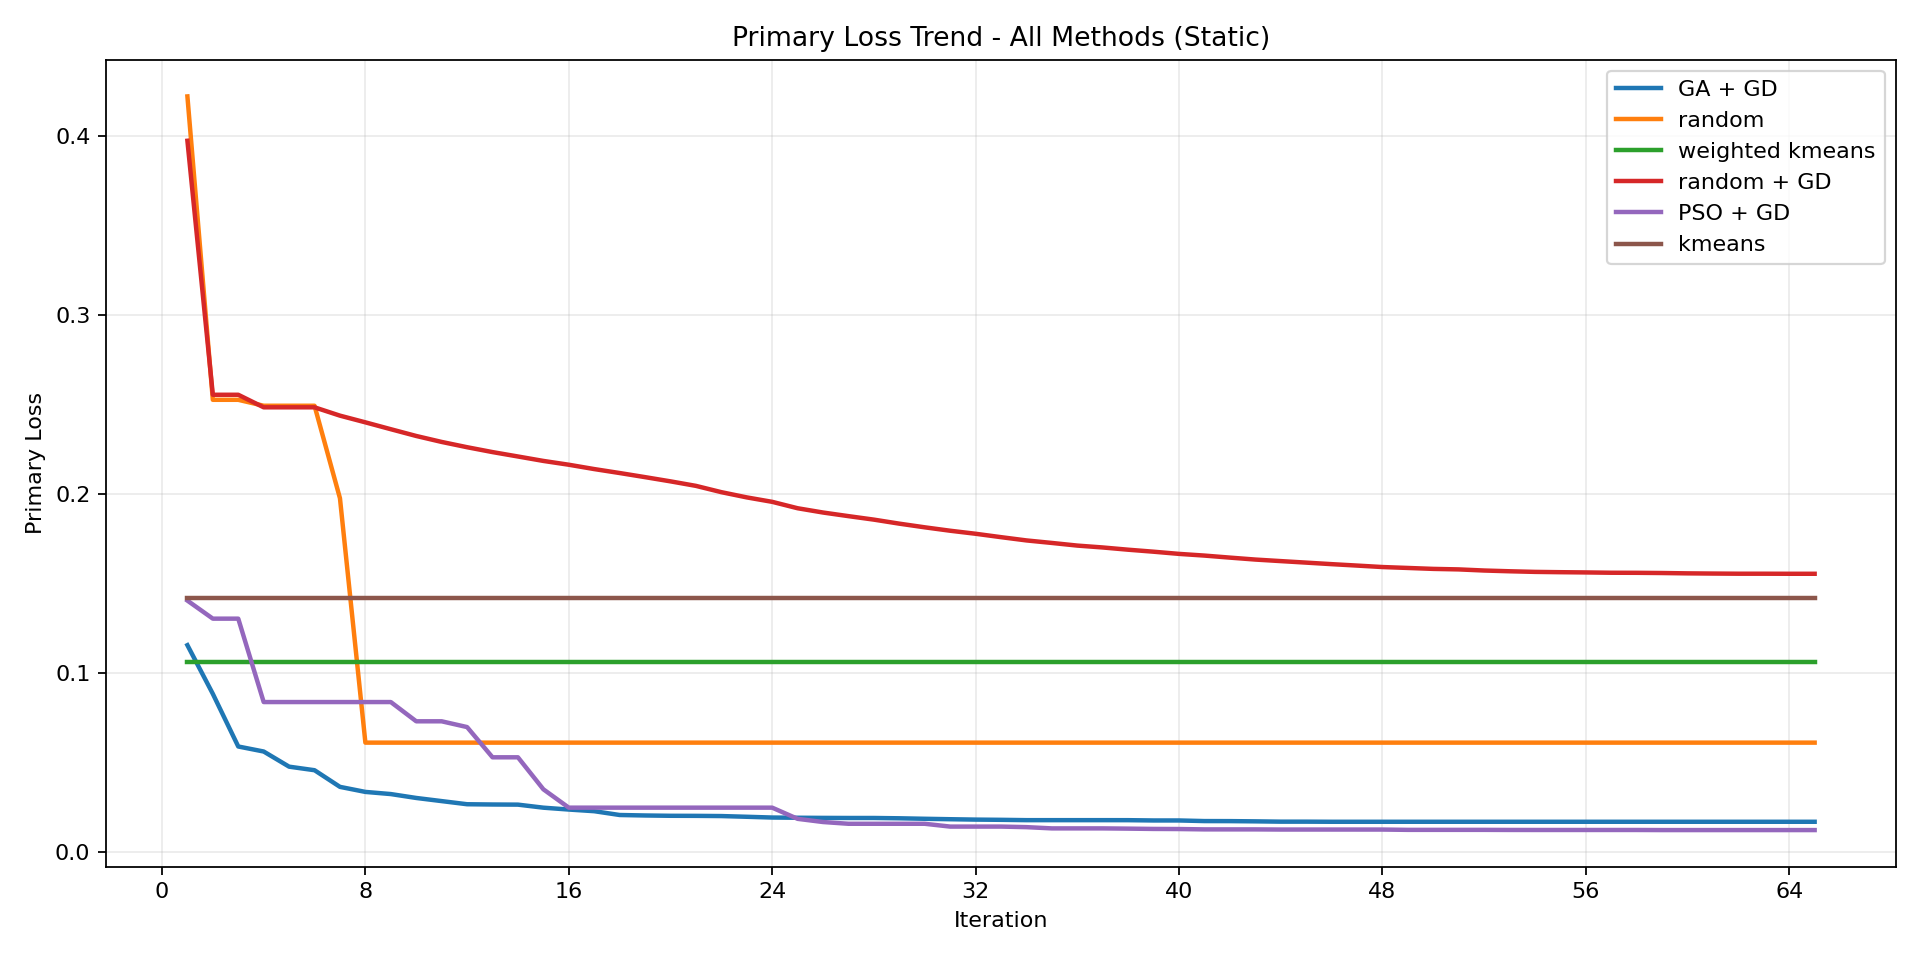

In [3]:
run_outputs = recreate_static_plots_from_trial_artifacts(
    artifacts_dir=ARTIFACTS_DIR,
    output_dir=OUTPUT_DIR,
    method_order=METHOD_ORDER,
    # rssi_y_limits=RSSI_Y_LIMITS,
)

print("Methods used:", run_outputs["methods"])
print("Output directory:", run_outputs["output_dir"])
print("Manifest:", run_outputs["manifest_path"])

display_recreated_cross_method_plots(run_outputs["plot_artifacts"])